Part 1: Setup & Import Libraries

In [9]:
# Import necessary libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Download NLTK resources (Run once)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Part 2: Load Dataset

In [10]:
# Load the dataset
print("Loading dataset...")
df = pd.read_csv("amazon_neww.csv")

# Display all column names to verify
print("\nColumns in the dataset:")
print(df.columns.tolist())

Loading dataset...

Columns in the dataset:
['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'Updated_Rating', 'rating_count', 'about_product', 'user_id', 'Column1', 'user_name', 'review_title', 'review_content']


# Part 2.5: Match Users and Remove Invalid Data

In [11]:
# Part 2.5: Match Users Safely and Remove Invalid Data

print("Matching user_id with user_name safely...")

# 1. Convert comma-separated strings into lists
df['user_id'] = df['user_id'].astype(str).str.split(',')
df['user_name'] = df['user_name'].astype(str).str.split(',')

# 2. Bind the ID and Name together into pairs using zip()
# This safely handles rows where the number of IDs doesn't match the number of Names
df['paired_user'] = df.apply(
    lambda row: list(zip(row['user_id'], row['user_name'])) 
    if isinstance(row['user_id'], list) and isinstance(row['user_name'], list) 
    else [], 
    axis=1
)

# 3. Explode the paired column (This prevents the ValueError)
df = df.explode('paired_user')

# 4. Split the pairs back into their respective columns
df['user_id'] = df['paired_user'].apply(lambda x: x[0] if isinstance(x, tuple) else "")
df['user_name'] = df['paired_user'].apply(lambda x: x[1] if isinstance(x, tuple) else "")

# 5. Clean up extra spaces
df['user_id'] = df['user_id'].str.strip()
df['user_name'] = df['user_name'].str.strip()

# 6. Drop the temporary 'paired_user' column
df = df.drop(columns=['paired_user'])

# 7. Filter out invalid data (e.g., 'HUL', 'XIOMI', 'VR')
# Keep only rows where user_id is exactly 28 characters long
df = df[df['user_id'].str.len() == 28]

# 8. Reset the row index for a clean dataframe
df = df.reset_index(drop=True)

print("Matching and filtering completed successfully!")
print(df[['user_id', 'user_name']].head())

Matching user_id with user_name safely...
Matching and filtering completed successfully!
                        user_id       user_name
0  AG3D6O4STAQKAY2UVGEUV46KN35Q           Manav
1  AHMY5CWJMMK5BJRBBSNLYT3ONILA    Adarsh gupta
2  AHCTC6ULH4XB6YHDY6PCH2R772LQ         Sundeep
3  AGYHHIERNXKA6P5T7CZLXKVPT7IQ  S.Sayeed Ahmed
4  AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q  jaspreet singh


Part 3: Drop Empty Rows & Clean Text

In [3]:
# Set the target column based on the dataset
target_column = 'review_content'

# Remove rows with empty reviews
df = df.dropna(subset=[target_column])
df = df[df[target_column].astype(str).str.strip() != ""]

# Function to clean text
def clean_text(text):
    text = str(text).lower()                 # Convert to lowercase
    text = re.sub(r'<.*?>', '', text)        # Remove HTML tags
    text = re.sub(r'http\S+', '', text)      # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# Apply text cleaning
print("Cleaning text data...")
df['clean_review'] = df[target_column].apply(clean_text)
print("Text cleaning completed!")

Cleaning text data...
Text cleaning completed!


Part 4: NLP Preprocessing (Tokenize, Stopwords, Stemming)

In [4]:
print("Starting NLP processing...")

# 1. Tokenization (Split sentences into words)
df['tokens'] = df['clean_review'].apply(word_tokenize)

# 2. Stopword removal (Remove common words like 'is', 'the', 'and')
stop_words = set(stopwords.words('english'))
df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# 3. Stemming (Reduce words to their root form, e.g., 'charging' -> 'charg')
stemmer = PorterStemmer()
df['stemmed_words'] = df['tokens_no_stopwords'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

# 4. Join processed words back into a single string
df['processed_review'] = df['stemmed_words'].apply(lambda x: " ".join(x))

print("\nResults after NLP processing:")
print(df[['clean_review', 'processed_review']].head())

Starting NLP processing...

Results after NLP processing:
                                        clean_review  \
0                                                ske   
1  not quite durable and sturdy good nice product...   
2                                              xiomi   
3  bought this instead of original apple does the...   
4  its a good productlikevery good item strong an...   

                                    processed_review  
0                                                ske  
1  quit durabl sturdi good nice productwork welli...  
2                                              xiomi  
3  bought instead origin appl work rs fast appl c...  
4  good productlikeveri good item strong use usb ...  


In [12]:
# Part 5: Export Cleaned Data

# Save the cleaned and processed data to a new CSV file
df.to_csv("amazon_nlp_ready.csv", index=False)
print("Success! The file 'amazon_nlp_ready.csv' has been saved and is ready for visualization.")

Success! The file 'amazon_nlp_ready.csv' has been saved and is ready for visualization.


In [13]:
# Convert rating to numeric just to be safe
df["rating"] = pd.to_numeric(df["rating"], errors='coerce')

# Define the labeling function
def sentiment_label(rating):
    if pd.isna(rating):
        return "Unknown"      # Pelindung untuk kotak kosong
    elif rating >= 4:
        return "Satisfied"    
    elif rating == 3:
        return "Neutral"      
    else:
        return "Low"          

# Apply function and create new Sentiment column
df["Sentiment"] = df["rating"].apply(sentiment_label)

# Display the result
print(df[['rating', 'Sentiment']].head())

   rating  Sentiment
0     4.2  Satisfied
1     4.2  Satisfied
2     4.2  Satisfied
3     4.2  Satisfied
4     4.2  Satisfied


In [18]:
# Import all required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# 1. Ensure rating is numeric and create the Sentiment labels ('satisfied', 'neutral', 'low')
df["rating"] = pd.to_numeric(df["rating"], errors='coerce')

def sentiment_label(rating):
    if pd.isna(rating):
        return "Unknown"
    elif rating >= 4:
        return "Satisfied"
    elif rating == 3:
        return "Neutral"
    else:
        return "Low"

df["Sentiment"] = df["rating"].apply(sentiment_label)

# 2. Text Cleaning & NLP Preprocessing (This creates 'processed_review')
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Make sure to target your actual review text column name ('review_content')
df['clean_review'] = df['review_content'].apply(clean_text)

# Tokenization, stopword removal, and stemming
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def process_nlp(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed)

df['processed_review'] = df['clean_review'].apply(process_nlp)

# 3. Clean up missing data before training
df = df.dropna(subset=['processed_review', 'Sentiment'])
df = df[df['Sentiment'] != 'Unknown']

# 4. Define Features (X) and Target (y)
X = df['processed_review']
y = df['Sentiment']

# 5. Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 7. Train the Machine Learning model
print("Training Logistic Regression model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 8. Predict and Evaluate
y_pred = model.predict(X_test_tfidf)

print("\n--- EVALUATION RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Logistic Regression model...

--- EVALUATION RESULTS ---
Accuracy: 0.8417391304347827

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.44      0.59       149
   Satisfied       0.83      0.98      0.90       426

    accuracy                           0.84       575
   macro avg       0.87      0.71      0.75       575
weighted avg       0.85      0.84      0.82       575


Confusion Matrix:
[[ 65  84]
 [  7 419]]


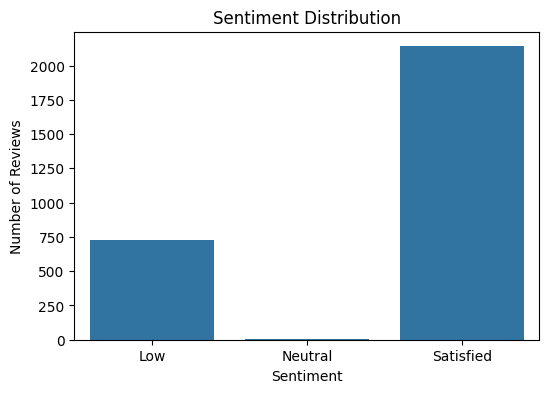

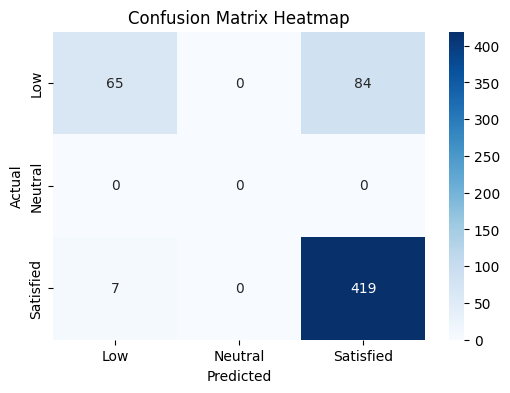

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Sentiment distribution in full dataset
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment', order=['Low', 'Neutral', 'Satisfied'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Neutral', 'Satisfied'])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Neutral', 'Satisfied'],
    yticklabels=['Low', 'Neutral', 'Satisfied']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

print("Preparing document-term matrix for Topic Modeling...")

# LDA requires word counts (Bag of Words) instead of TF-IDF
count_vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_counts = count_vectorizer.fit_transform(df['processed_review'])

print("Matrix created successfully!")

Preparing document-term matrix for Topic Modeling...
Matrix created successfully!


In [21]:
from sklearn.decomposition import LatentDirichletAllocation

# Define the number of topics you want the model to discover
n_topics = 3

print(f"Training LDA model to find {n_topics} main topics...")
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_output = lda_model.fit_transform(X_counts)

print("LDA model training completed!")

Training LDA model to find 3 main topics...
LDA model training completed!


In [22]:
# Function to print the top words for each discovered topic
def display_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        print(f"Topic #{topic_idx + 1}:")
        print(" ".join(top_features))
        print("-" * 60)

# Get feature names from the vectorizer
tf_feature_names = count_vectorizer.get_feature_names_out()
display_top_words(lda_model, tf_feature_names, n_top_words=10)

Topic #1:
charg cabl product good use qualiti work eco long fast
------------------------------------------------------------
Topic #2:
good use product qualiti look item price amazon like support
------------------------------------------------------------
Topic #3:
xiomi good product work use easi like fit nice need
------------------------------------------------------------


In [23]:
import numpy as np

# Find the highest probability topic for each review and assign it
df['Dominant_Topic'] = np.argmax(lda_output, axis=1) + 1

# Display the preview of the updated dataframe
print("\nDataset with assigned Topic column:")
print(df[['processed_review', 'Dominant_Topic']].head(10))

# Optional: Save the updated dataset with both Sentiment and Topics
df.to_csv("amazon_final_analyzed.csv", index=False)
print("\nSuccess! The final dataset with Sentiment and Topics has been saved as 'amazon_final_analyzed.csv'.")


Dataset with assigned Topic column:
                                    processed_review  Dominant_Topic
0                                                ske               2
1                                                ske               2
2                                                ske               2
3                                                ske               2
4                                                ske               2
5  quit durabl sturdi good nice productwork welli...               1
6  quit durabl sturdi good nice productwork welli...               1
7  quit durabl sturdi good nice productwork welli...               1
8                                              xiomi               3
9                                              xiomi               3

Success! The final dataset with Sentiment and Topics has been saved as 'amazon_final_analyzed.csv'.


<Figure size 1000x500 with 0 Axes>

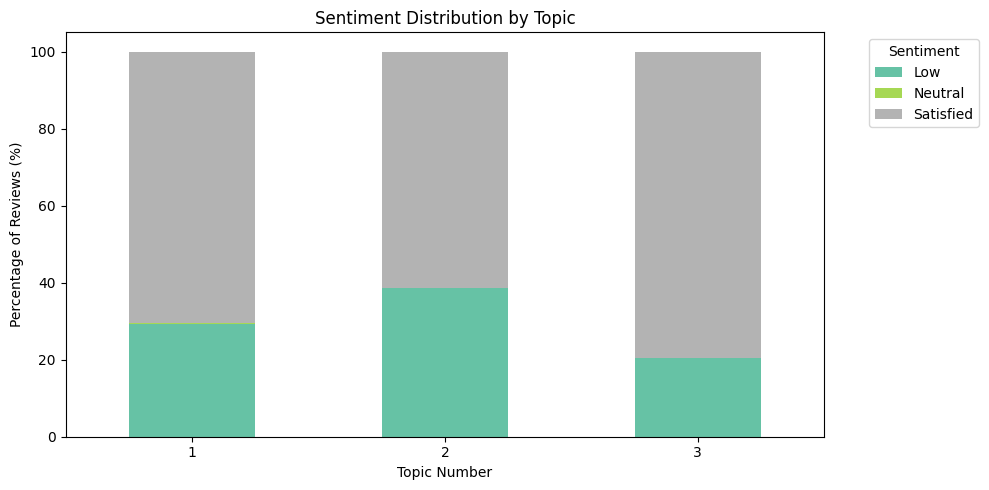

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a crosstab between Dominant_Topic and Sentiment, then convert to percentage (normalize='index' * 100)
sentiment_by_topic = pd.crosstab(df['Dominant_Topic'], df['Sentiment'], normalize='index') * 100

# 2. Ensure the columns follow the correct order if they exist
existing_cols = [col for col in ['Low', 'Neutral', 'Satisfied'] if col in sentiment_by_topic.columns]
sentiment_by_topic = sentiment_by_topic[existing_cols]

# 3. Plot the stacked bar chart
plt.figure(figsize=(10, 5))
sentiment_by_topic.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.title("Sentiment Distribution by Topic")
plt.xlabel("Topic Number")
plt.ylabel("Percentage of Reviews (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

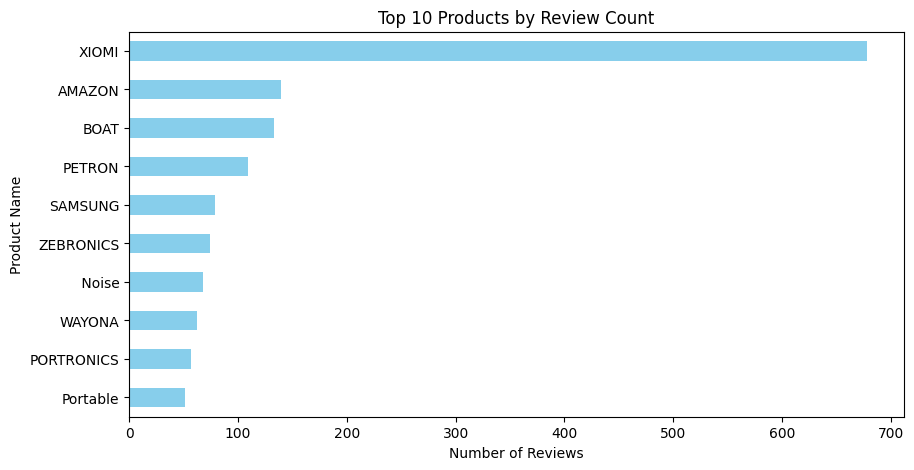

In [25]:
import matplotlib.pyplot as plt

# 1. Get the top 10 products with the highest number of reviews
top_products = df['product_name'].value_counts().head(10)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 5))
top_products.sort_values().plot(kind="barh", color="skyblue")
plt.title("Top 10 Products by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Name")
plt.show()

In [27]:
# Save the final dataframe into a CSV file for Tableau dashboard
output_file = "amazon_tableau_ready.csv"

# index=False ensures that pandas doesn't save the extra row numbers column
df.to_csv(output_file, index=False, encoding='utf-8')

print(f"Success! File saved as '{output_file}' and is ready to be imported into Tableau.")

Success! File saved as 'amazon_tableau_ready.csv' and is ready to be imported into Tableau.
